# Notebook 1: Gradient Flow ODE Simulator

Implements the gradient flow ODEs for a shallow ReLU network and reproduces the empirical demonstration from Project 4 slides.

**Model:** $f(x) = \sum_{j=1}^m a_j \sigma(x - b_j)$, $\sigma(z) = \max(0,z)$, $x \in [-1,1]$

**ODEs:**
$$\dot{a}_j = -\int_{-1}^{1} (f(x) - f^*(x))\,\sigma(x - b_j)\,dx$$
$$\dot{b}_j = a_j \int_{b_j}^{1} (f(x) - f^*(x))\,dx$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## Core Functions

In [2]:
def relu(z):
    return np.maximum(0.0, z)

def network(x, a, b):
    """Evaluate the ReLU network at points x.
    x: (N,)  a,b: (m,)  returns (N,)
    """
    # shape: (N, m)
    return (a * relu(x[:, None] - b[None, :])).sum(axis=1)

def target(x):
    """Default target: sin(2*pi*x) + 0.5*sin(4*pi*x)"""
    return np.sin(2 * np.pi * x) + 0.5 * np.sin(4 * np.pi * x)

# Quadrature grid — fixed throughout integration for speed
N_QUAD = 400
X_QUAD = np.linspace(-1, 1, N_QUAD)
DX = X_QUAD[1] - X_QUAD[0]

In [3]:
def make_ode(m, f_star, x_quad=X_QUAD, dx=DX):
    """
    Returns the ODE right-hand side for scipy.integrate.solve_ivp.
    State vector: y = [a_1,...,a_m, b_1,...,b_m]  shape (2m,)
    """
    fstar_vals = f_star(x_quad)  # precompute target on quad grid

    def ode(t, y):
        a = y[:m]
        b = y[m:]

        # network on quad grid  (N,)
        f_vals = network(x_quad, a, b)
        residual = f_vals - fstar_vals  # (N,)

        # Amplitude ODE: da_j/dt = -int residual * sigma(x - b_j) dx
        # relu_mat shape (N, m)
        relu_mat = relu(x_quad[:, None] - b[None, :])  # (N, m)
        da = -(residual[:, None] * relu_mat).sum(axis=0) * dx  # (m,)

        # Bias ODE: db_j/dt = a_j * int_{b_j}^{1} residual dx
        # Compute cumulative sum from right: cum_right[i] = integral from x_quad[i] to 1
        cum_right = np.cumsum(residual[::-1])[::-1] * dx  # (N,)

        # For each b_j, find index of b_j in x_quad and look up the cumulative integral
        # Clamp indices to valid range
        idx = np.searchsorted(x_quad, b).clip(0, N_QUAD - 1)
        integral_right = cum_right[idx]  # (m,)
        db = a * integral_right  # (m,)

        return np.concatenate([da, db])

    return ode

## Run the Simulation

In [4]:
np.random.seed(42)

m = 100
T = 80.0        # integration time (gradient flow "time")
N_SAVE = 500    # number of time snapshots to save

# Initial conditions: biases uniform in [-1,1], amplitudes small random
a0 = np.random.randn(m) * 0.01
b0 = np.random.uniform(-1, 1, m)
y0 = np.concatenate([a0, b0])

ode_fn = make_ode(m, target)

print(f"Integrating m={m} neurons for t=[0, {T}] ...")
sol = solve_ivp(
    ode_fn,
    t_span=(0, T),
    y0=y0,
    method='RK45',
    t_eval=np.linspace(0, T, N_SAVE),
    rtol=1e-4,
    atol=1e-6,
    max_step=0.1,
)
print(f"Done. Status: {sol.message}")

Integrating m=100 neurons for t=[0, 80.0] ...


Done. Status: The solver successfully reached the end of the integration interval.


## Compute Loss Over Time

In [5]:
fstar_vals = target(X_QUAD)

losses = []
for i in range(sol.y.shape[1]):
    a_i = sol.y[:m, i]
    b_i = sol.y[m:, i]
    f_vals = network(X_QUAD, a_i, b_i)
    loss = 0.5 * np.trapz((f_vals - fstar_vals)**2, X_QUAD)
    losses.append(loss)
losses = np.array(losses)

C:\Users\cal3b\AppData\Local\Temp\claude\ipykernel_18816\1432503204.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  loss = 0.5 * np.trapz((f_vals - fstar_vals)**2, X_QUAD)


## Reproduce Slide 93 Figure

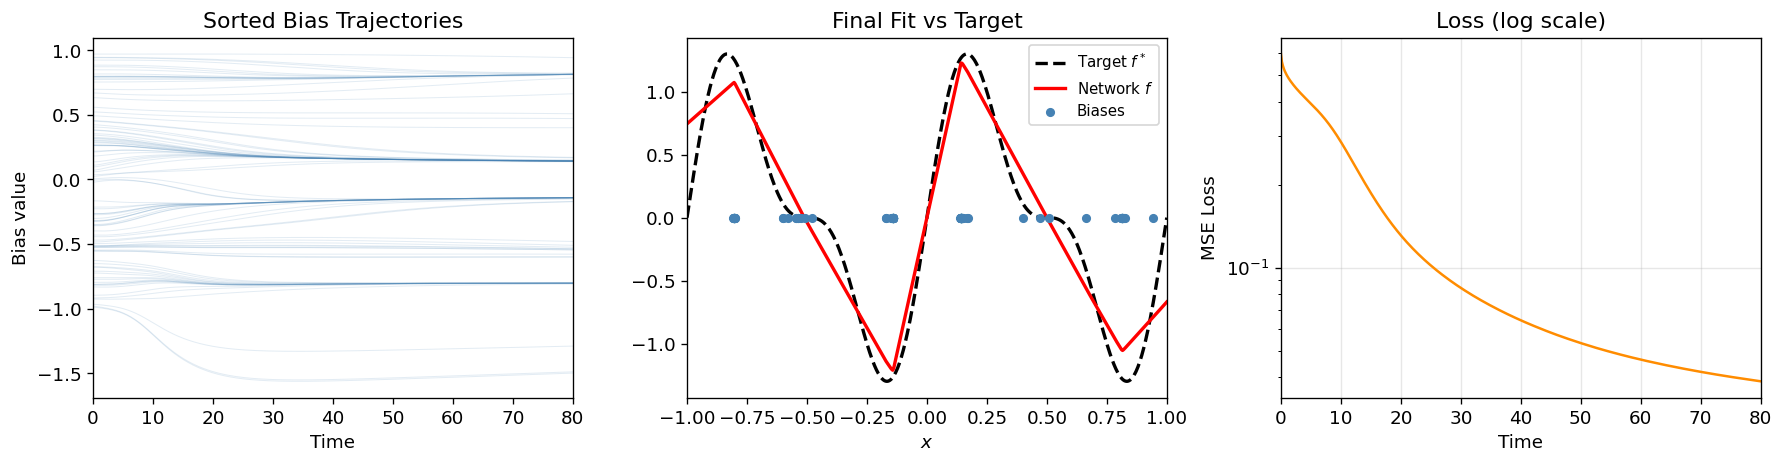

Final MSE loss: 0.038740


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Sorted bias trajectories ---
ax = axes[0]
biases_over_time = sol.y[m:, :]  # shape (m, N_SAVE)
sorted_biases = np.sort(biases_over_time, axis=0)  # sort each column
for j in range(m):
    ax.plot(sol.t, sorted_biases[j], color='steelblue', alpha=0.15, linewidth=0.6)
ax.set_xlabel('Time')
ax.set_ylabel('Bias value')
ax.set_title('Sorted Bias Trajectories')
ax.set_xlim([0, T])

# --- Plot 2: Final fit vs target ---
ax = axes[1]
a_final = sol.y[:m, -1]
b_final = sol.y[m:, -1]
x_plot = np.linspace(-1, 1, 500)
f_final = network(x_plot, a_final, b_final)
ax.plot(x_plot, target(x_plot), 'k--', linewidth=2, label='Target $f^*$')
ax.plot(x_plot, f_final, 'r-', linewidth=2, label='Network $f$')
ax.scatter(b_final, np.zeros_like(b_final), c='steelblue', s=20, zorder=5, label='Biases')
ax.set_xlabel('$x$')
ax.set_title('Final Fit vs Target')
ax.legend(fontsize=9)
ax.set_xlim([-1, 1])

# --- Plot 3: Loss on log scale ---
ax = axes[2]
ax.semilogy(sol.t, losses, color='darkorange', linewidth=1.5)
ax.set_xlabel('Time')
ax.set_ylabel('MSE Loss')
ax.set_title('Loss (log scale)')
ax.set_xlim([0, T])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/slide93_reproduction.png', bbox_inches='tight')
plt.show()
print(f"Final MSE loss: {losses[-1]:.6f}")

## Count Clusters at Convergence

In [7]:
def count_clusters(biases, tol=0.02):
    """Count distinct clusters among biases using single-linkage with tolerance tol."""
    sorted_b = np.sort(biases)
    clusters = 1
    for i in range(1, len(sorted_b)):
        if sorted_b[i] - sorted_b[i-1] > tol:
            clusters += 1
    return clusters

def get_cluster_centers(biases, tol=0.02):
    """Return the centroid of each cluster."""
    sorted_b = np.sort(biases)
    centers = []
    group = [sorted_b[0]]
    for i in range(1, len(sorted_b)):
        if sorted_b[i] - sorted_b[i-1] > tol:
            centers.append(np.mean(group))
            group = []
        group.append(sorted_b[i])
    centers.append(np.mean(group))
    return np.array(centers)

n_clusters = count_clusters(b_final)
cluster_centers = get_cluster_centers(b_final)
print(f"Number of clusters at t={T}: {n_clusters}")
print(f"Cluster centers: {np.round(cluster_centers, 4)}")

Number of clusters at t=80.0: 16
Cluster centers: [-1.4947 -1.2904 -0.8033 -0.5999 -0.5784 -0.533  -0.4801 -0.1446  0.145
  0.4009  0.4718  0.5094  0.6638  0.7855  0.8153  0.9435]


## Count Inflection Points of Target

In [8]:
def count_inflection_points(f_star, n=2000):
    """Estimate inflection points by counting sign changes of the numerical second derivative."""
    x = np.linspace(-1, 1, n)
    y = f_star(x)
    d2y = np.gradient(np.gradient(y, x), x)
    sign_changes = np.sum(np.diff(np.sign(d2y)) != 0)
    return sign_changes

n_inflections = count_inflection_points(target)
print(f"Estimated inflection points of target: {n_inflections}")
print(f"Number of bias clusters:               {n_clusters}")

Estimated inflection points of target: 7
Number of bias clusters:               16


## Cluster Locations vs Inflection Points

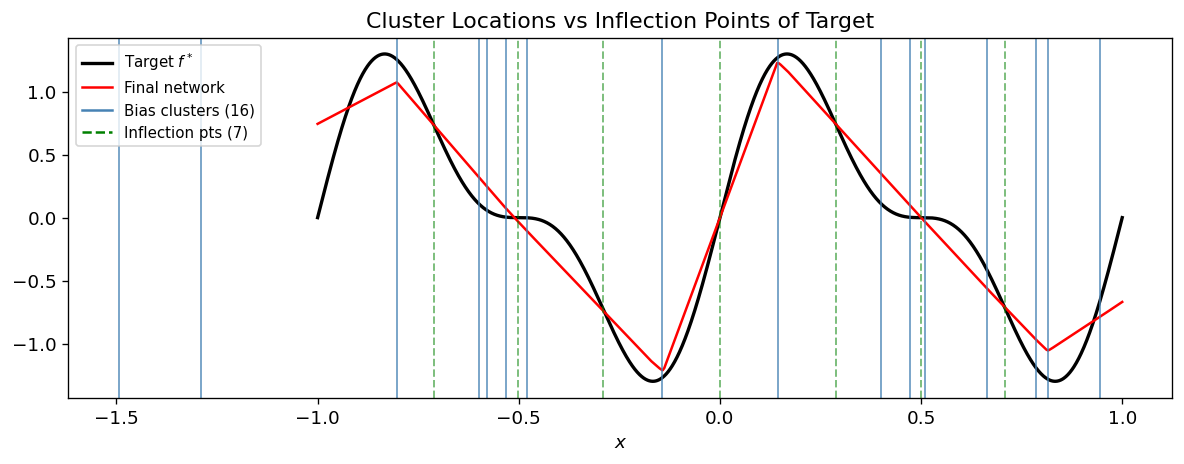

In [9]:
x_fine = np.linspace(-1, 1, 2000)
fstar_fine = target(x_fine)
d2f = np.gradient(np.gradient(fstar_fine, x_fine), x_fine)
sign_d2f = np.sign(d2f)
inflection_mask = np.diff(sign_d2f) != 0
inflection_x = x_fine[:-1][inflection_mask]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_fine, fstar_fine, 'k-', linewidth=2, label='Target $f^*$')
ax.plot(x_plot, f_final, 'r-', linewidth=1.5, label='Final network')
for cx in cluster_centers:
    ax.axvline(cx, color='steelblue', alpha=0.7, linewidth=1.2, linestyle='-')
for ix in inflection_x:
    ax.axvline(ix, color='green', alpha=0.5, linewidth=1.2, linestyle='--')
# Legend proxies
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([0],[0],color='steelblue',lw=1.5,label=f'Bias clusters ({n_clusters})'),
            Line2D([0],[0],color='green',lw=1.5,ls='--',label=f'Inflection pts ({len(inflection_x)})')]
ax.legend(handles=handles, fontsize=9)
ax.set_xlabel('$x$')
ax.set_title('Cluster Locations vs Inflection Points of Target')
plt.tight_layout()
plt.savefig('../figures/clusters_vs_inflections.png', bbox_inches='tight')
plt.show()

## Save Results for Notebook 2

In [10]:
import os
os.makedirs('../data', exist_ok=True)

np.save('../data/sol_t.npy', sol.t)
np.save('../data/sol_y.npy', sol.y)
np.save('../data/losses.npy', losses)
print("Results saved to ../data/")

Results saved to ../data/
